In [1]:
def plot_fiber_only_map(ref_lat, ref_lon, das_hyb, earthquake_location,
                        corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
                        lat_range, lon_range, fiber_file,
                        title="Fiber Coherence Map", event_name=None, ax=None):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from matplotlib.lines import Line2D
    from scipy.interpolate import griddata
    import numpy as np
    import os

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    file_dir = os.path.dirname(fiber_file)

    # Normalize the coherence matrix
    corrmatrix = corrmatrix_das / np.nanmax(corrmatrix_das)
    nx, ny, nz = np.shape(corrmatrix)
    CXY = np.max(corrmatrix, axis=2).T

    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, ref_lat, ref_lon)

    lat_lin = np.linspace(lat_range[0], lat_range[1], ny)
    lon_lin = np.linspace(lon_range[0], lon_range[1], nx)
    grid_lon, grid_lat = np.meshgrid(lon_lin, lat_lin)

    interpolated_CXY = griddata(
        (lat_grid.flatten(), lon_grid.flatten()), 
        CXY.flatten(), 
        (grid_lat, grid_lon), 
        method='cubic'
    )

    # If no axis is provided, create a new figure
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
        created_fig = True
    else:
        fig = ax.get_figure()

    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.2), labels=[1,0,0,0], fontsize=8)
    m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.2), labels=[0,0,0,1], fontsize=8)

    cs = ax.contourf(grid_lon, grid_lat, interpolated_CXY, levels=20, cmap='viridis', alpha=0.8)

    # 99th percentile contour
    percentile_95 = np.nanpercentile(interpolated_CXY, 99)
    ax.contour(grid_lon, grid_lat, interpolated_CXY, levels=[percentile_95], colors='red', linewidths=1.5, linestyles='--')

    # Earthquake catalog location
    ax.scatter(earthquake_location[1], earthquake_location[0], marker='*', color='red', edgecolors='black', s=130, label='Catalog Location')

    # Max coherence location
    max_index = np.unravel_index(np.nanargmax(interpolated_CXY), interpolated_CXY.shape)
    max_lat = grid_lat[max_index]
    max_lon = grid_lon[max_index]
    print(f"Max Coherence Location, lat, lon: {max_lat}, {max_lon}")
    ax.scatter(max_lon, max_lat, marker='*', facecolors='none', edgecolors='black', s=130, label='Max Coherence')

    # Plot DAS HYB points
    for name, (lat, lon) in das_hyb.items():
        ax.scatter(lon, lat, marker='o', color='crimson', s=14)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    if created_fig:
        cbar = fig.colorbar(cs, ax=ax, orientation='vertical', pad=0.02, shrink=0.5, aspect=20)
        cbar.set_label('Normalized Coherence')

    # Legend
    custom_handles = [
        Line2D([0], [0], marker='*', color='red', label='Cluster center', markersize=12, linestyle='', markeredgecolor='black'),
        Line2D([0], [0], marker='*', color='none', label='Max Coherence', markersize=12, linestyle='', markeredgecolor='black'),
        Line2D([0], [0], color='red', lw=1.5, linestyle='--', label='99% Contour'),
        Line2D([0], [0], marker='o', color='crimson', label='DAS fiber', linestyle='', markersize=6)
    ]
    ax.legend(handles=custom_handles, loc='lower right', fontsize='small', frameon=True)

    if created_fig:
        output_file = os.path.join(file_dir, f"{event_name}_fiber_map.pdf" if event_name else "fiber_map.pdf")
        plt.savefig(output_file, bbox_inches='tight')
        plt.show()



--- Processing Event 'cluster' for 'Orion' ---
Max Coherence Location, lat, lon: 38.431021021021024, 20.591834573050043

--- Processing Event 'cluster' for 'Random' ---
Max Coherence Location, lat, lon: 38.431021021021024, 20.591834573050043


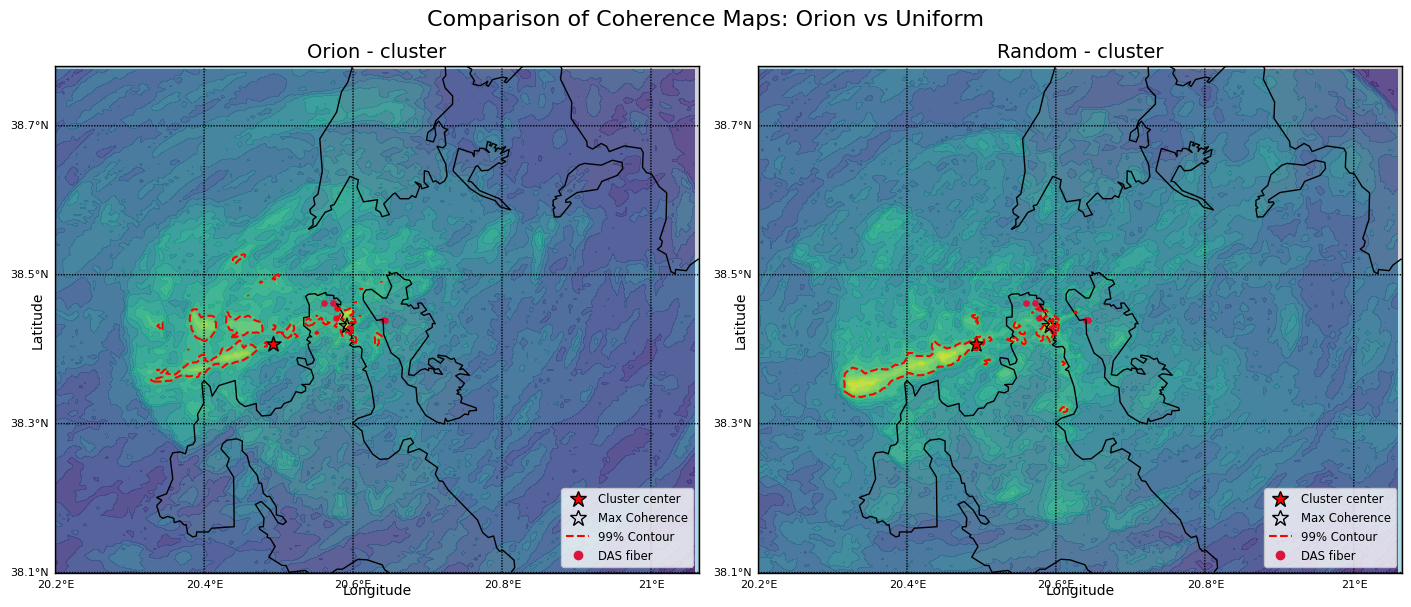

In [9]:
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Reference Coordinates ---
ref_lat = 38.10
ref_lon = 20.20

# --- DAS Hybrid Geometry ---
das_hyb = {
    "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
    "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
    "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
    "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
    "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
    "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
    "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
    "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
}

# --- Grid Parameters ---
nx = ny = nz = 151
dx = dz = 0.5

cartesian_grid_x, cartesian_grid_y = np.meshgrid(np.linspace(0, 75.5, nx), np.linspace(0, 75.5, ny))
lat_range = (ref_lat, ref_lat + nx * dx / 111)
lon_range = (ref_lon, ref_lon + ny * dx / (111 * np.cos(np.radians(ref_lat))))

# --- Event List ---
events = {
    'cluster': (38.407538, 20.4923, 14.5),
}

# --- Data Roots ---
base_dirs = {
    "Orion": "/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_orion",
    "Random": "/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_uniform"
}


def select_highest_coherence_file(folder):
    loc_file = os.path.join(folder, "fiber.loc")
    if not os.path.isfile(loc_file):
        raise FileNotFoundError(f"Missing .loc file: {loc_file}")

    catalog = np.loadtxt(loc_file)
    if catalog.ndim == 1:
        catalog = catalog[np.newaxis, :]

    coherence = catalog[:, 4]
    max_idx = np.argmax(coherence)

    npy_file = os.path.join(folder, f"corrmatrix_trial_{max_idx}_fiber.npy")
    if not os.path.isfile(npy_file):
        raise FileNotFoundError(f"Missing .npy file: {npy_file}")

    return npy_file


# --- Plotting Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, (label, base_dir) in zip(axes, base_dirs.items()):
    try:
        fiber_file = select_highest_coherence_file(base_dir)
        corrmatrix_das = np.load(fiber_file).reshape((nx, ny, nz))
    except Exception as e:
        print(f"Error loading coherence file for {label}: {e}")
        continue

    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for '{label}' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file,
            title=f"{label} - {name}", event_name=name,
            ax=ax  # This assumes your function supports 'ax' parameter
        )

plt.suptitle("Comparison of Coherence Maps: Orion vs Uniform", fontsize=16)
plt.show()



--- Processing Event 'catalog' for 'Orion' ---
Max Coherence Location, lat, lon: 38.43555555555556, 20.505400476053712

--- Processing Event 'catalog' for 'Random' ---
Max Coherence Location, lat, lon: 38.431021021021024, 20.470826837255178

--- Processing Event 'catalog' for 'Non-Selected' ---
Max Coherence Location, lat, lon: 38.41288288288288, 20.470826837255178


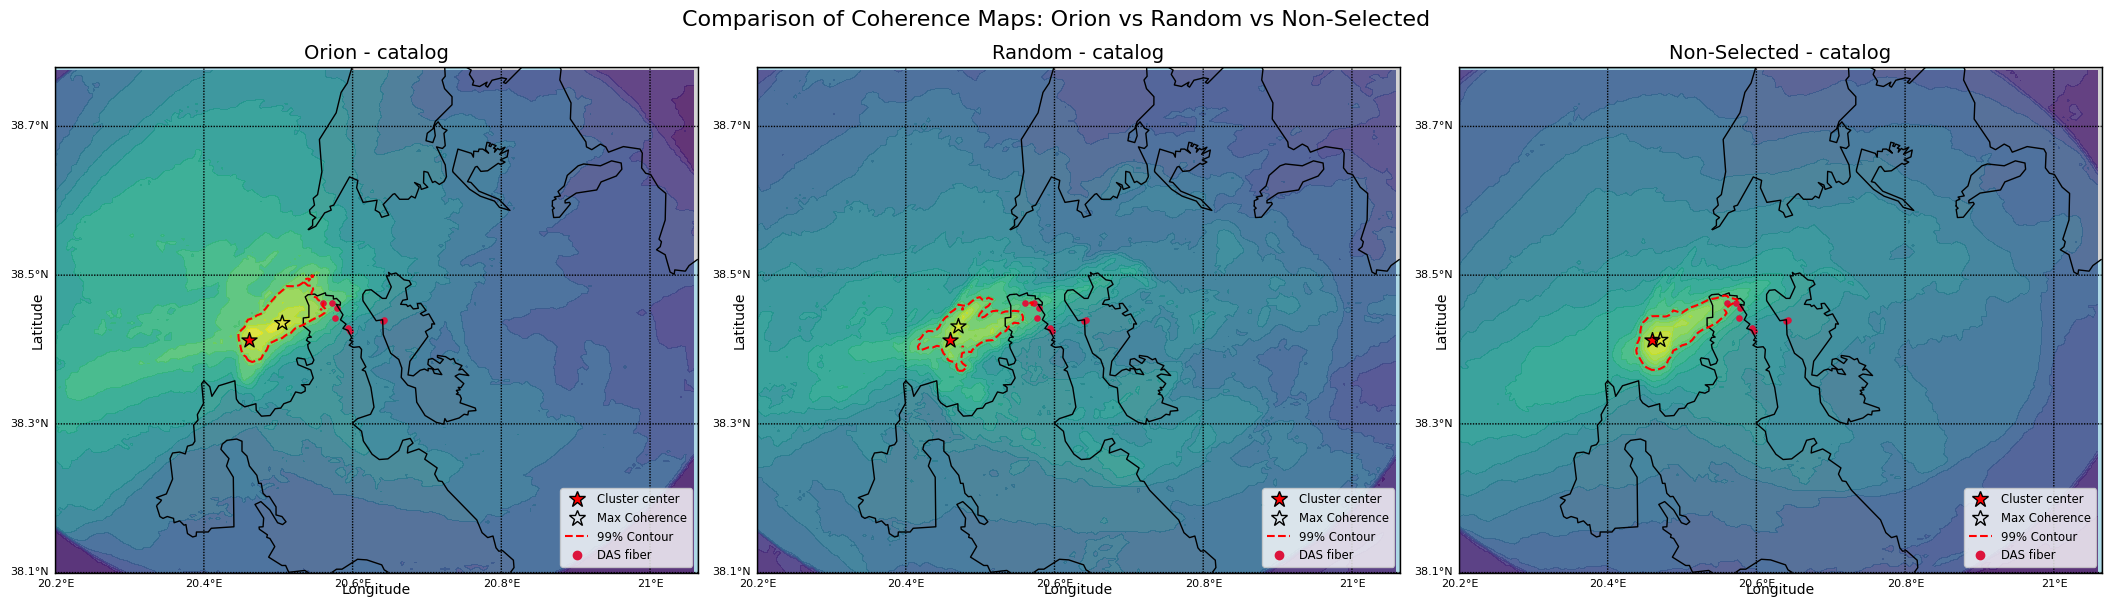

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

# --- Reference Coordinates ---
ref_lat = 38.10
ref_lon = 20.20

# --- DAS Hybrid Geometry ---
das_hyb = {
    "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
    "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
    "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
    "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
    "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
    "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
    "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
    "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
}

# --- Grid Parameters ---
nx = ny = nz = 151
dx = dz = 0.5

cartesian_grid_x, cartesian_grid_y = np.meshgrid(np.linspace(0, 75.5, nx), np.linspace(0, 75.5, ny))
lat_range = (ref_lat, ref_lat + nx * dx / 111)
lon_range = (ref_lon, ref_lon + ny * dx / (111 * np.cos(np.radians(ref_lat))))

# --- Event List ---
events = {
    'cluster': (38.3755, 20.4237, 14.5),
}

# --- Event List ---
#events = {
#    'catalog': (38.4075, 20.4237, 14.5),
#}



# --- Event List ---
#events = {
#    'catalog': (38.4124,20.4601, 14.5),
#}

#events = {
#    'catalog': (38.399,20.4735,14.5),
#}


# --- Data Roots ---
base_dirs = {
    "Orion": "/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_orion",
    "Random": "/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/fiber_random",
    "Non-Selected": "/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/kef0021/_non_selected"
}


def select_highest_coherence_file(folder):
    loc_file = os.path.join(folder, "fiber/fiber.loc")
    if not os.path.isfile(loc_file):
        raise FileNotFoundError(f"Missing .loc file: {loc_file}")

    catalog = np.loadtxt(loc_file)
    if catalog.ndim == 1:
        catalog = catalog[np.newaxis, :]

    coherence = catalog[:, 4]
    max_idx = np.argmax(coherence)

    npy_file = os.path.join(folder, f"fiber/corrmatrix_trial_{max_idx}_fiber.npy")
    if not os.path.isfile(npy_file):
        raise FileNotFoundError(f"Missing .npy file: {npy_file}")

    return npy_file


# --- Plotting ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

# --- Loop over each data version ---
for i, (label, base_dir) in enumerate(base_dirs.items()):
    ax = axes[i]
    try:
        fiber_file = select_highest_coherence_file(base_dir)
        corrmatrix_das = np.load(fiber_file).reshape((nx, ny, nz))
    except Exception as e:
        print(f"Error loading coherence file for {label}: {e}")
        continue

    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for '{label}' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file,
            title=f"{label} - {name}", event_name=name,
            ax=ax
        )

plt.suptitle("Comparison of Coherence Maps: Orion vs Random vs Non-Selected", fontsize=16)
plt.show()



--- Processing Event 'catalog' for 'Orion' ---
Max Coherence Location, lat, lon: 38.40381381381381, 20.45354001785591

--- Processing Event 'catalog' for 'Random' ---
Max Coherence Location, lat, lon: 38.503573573573576, 20.666744123780198

--- Processing Event 'catalog' for 'Non-Selected' ---
Max Coherence Location, lat, lon: 38.40834834834835, 20.45354001785591
Error loading non-selected coherence file: Not enough coherence entries to select a non-maximal value.


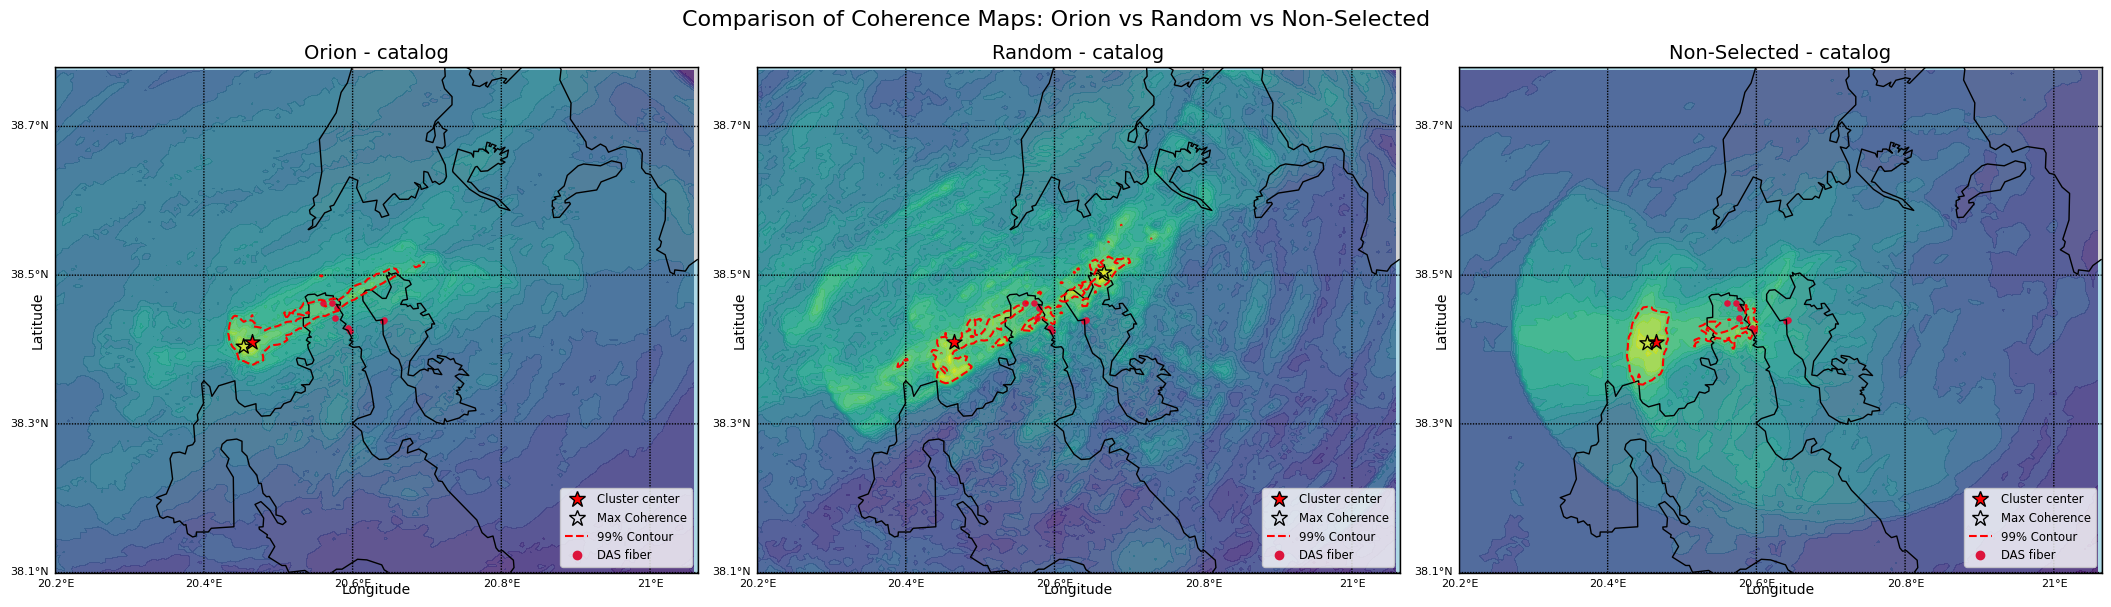

In [4]:
# --- Additional function to select non-maximal coherence file ---
def select_non_max_coherence_file(folder):
    loc_file = os.path.join(folder, "fiber/fiber.loc")
    if not os.path.isfile(loc_file):
        raise FileNotFoundError(f"Missing .loc file: {loc_file}")

    catalog = np.loadtxt(loc_file)
    if catalog.ndim == 1:
        catalog = catalog[np.newaxis, :]

    coherence = catalog[:, 4]
    if len(coherence) < 2:
        raise ValueError("Not enough coherence entries to select a non-maximal value.")

    sorted_indices = np.argsort(coherence)[::-1]  # Descending order
    second_idx = sorted_indices[1]

    npy_file = os.path.join(folder, f"fiber/corrmatrix_trial_{second_idx}_fiber.npy")
    if not os.path.isfile(npy_file):
        raise FileNotFoundError(f"Missing .npy file: {npy_file}")

    return npy_file

# --- Plotting Comparison with Third Panel ---
fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

for i, (label, base_dir) in enumerate(base_dirs.items()):
    ax = axes[i]
    try:
        fiber_file = select_highest_coherence_file(base_dir)
        corrmatrix_das = np.load(fiber_file).reshape((nx, ny, nz))
    except Exception as e:
        print(f"Error loading coherence file for {label}: {e}")
        continue

    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for '{label}' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file,
            title=f"{label} - {name}", event_name=name,
            ax=ax
        )

# --- Third subplot for non-selected trial (from Orion, for example) ---
try:
    fiber_file_non_selected = select_non_max_coherence_file(base_dirs["Orion"])
    corrmatrix_das_non_selected = np.load(fiber_file_non_selected).reshape((nx, ny, nz))
    for name, eq_loc in events.items():
        print(f"\n--- Processing Event '{name}' for 'Orion - Non-Selected' ---")
        plot_fiber_only_map(
            ref_lat, ref_lon, das_hyb, eq_loc,
            corrmatrix_das_non_selected, cartesian_grid_x, cartesian_grid_y,
            lat_range, lon_range, fiber_file_non_selected,
            title=f"Orion - Non-Selected - {name}", event_name=name,
            ax=axes[2]
        )
except Exception as e:
    print(f"Error loading non-selected coherence file: {e}")

plt.suptitle("Comparison of Coherence Maps: Orion vs Random vs Non-Selected", fontsize=16)
plt.show()


In [12]:
def plot_fiber_only_map_with_maxima_no_cat(ref_lat, ref_lon, das_hyb,
                                    earthquake_location, cartesian_grid_x,
                                    cartesian_grid_y, lat_range, lon_range,
                                    parent_folder,
                                    title="Fiber Maxima Map",
                                    magnitude_threshold=0.0):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    import numpy as np
    import os
    import glob
    import pandas as pd
    import re
    from math import radians, sin, cos, sqrt, atan2
    from numpy import median
    from scipy.stats import gaussian_kde
    from matplotlib.lines import Line2D

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0  # Earth radius in km
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        return R * c

    def collect_refined_max_locations_for_variant(parent_folder, event_id, variant_suffix):
        folder_name = f"{event_id}{variant_suffix}"
        event_path = os.path.join(parent_folder, folder_name, 'fiber')
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        npy_files = glob.glob(os.path.join(event_path, "corrmatrix_trial_*_fiber.npy"))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)

                window_size = 10
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 10
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)

                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]

                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)

                max_locations.append((lat_max, lon_max))

            except Exception:
                continue

        return max_locations

    def plot_50pct_contour(ax, coords, color, label):
        if len(coords) < 5:
            return None  # Not enough points for KDE

        coords = np.array(coords).T  # shape (2, N)
        kde = gaussian_kde(coords)
        # Create grid
        x_min, x_max = np.min(coords[0]), np.max(coords[0])
        y_min, y_max = np.min(coords[1]), np.max(coords[1])
        xgrid, ygrid = np.mgrid[x_min:x_max:1000j, y_min:y_max:1000j]
        grid_coords = np.vstack([xgrid.ravel(), ygrid.ravel()])
        kde_vals = kde(grid_coords)
        kde_vals = kde_vals.reshape(xgrid.shape)

        # Sort kde values and find contour level for 50% enclosed probability
        sorted_kde = np.sort(kde_vals.ravel())[::-1]  # descending
        cumsum = np.cumsum(sorted_kde)
        cumsum /= cumsum[-1]
        level = sorted_kde[np.searchsorted(cumsum, 0.5)]

        # Plot contour without label (we'll add proxy artist)
        ax.contour(xgrid, ygrid, kde_vals, levels=[level], colors=[color], linestyles='dashed', linewidths=4, alpha=0.7)

        # Return proxy artist for legend
        return Line2D([0], [0], color=color, lw=2, label=label)

    # Load catalog
    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    catalog_df['evid'] = catalog_df['evid'].astype(str)
    magnitude_dict = dict(zip(catalog_df['evid'], catalog_df['ML']))

    # Detect event IDs
    folder_list = os.listdir(parent_folder)
    pattern = re.compile(r'^(.*)_(orion|random)$')
    event_ids = set()
    for folder in folder_list:
        m = pattern.match(folder)
        if m:
            event_ids.add(m.group(1))

    #event_ids = sorted(list(event_ids))
    event_ids = sorted([
        eid for eid in event_ids
        if re.search(r'\d+', eid) and int(re.search(r'\d+', eid).group()) <= 1000
    ])


    # Define circle size scaling function (reuse your formula)
    def marker_size_from_magnitude(mag, base_size=5, scale_factor=25):
        return base_size + scale_factor * mag

    # --- Map Plot ---
    fig, ax = plt.subplots(figsize=(7, 7), dpi=300)
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='f', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.1), labels=[1, 0, 0, 0], fontsize=8)
    m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.1), labels=[0, 0, 0, 1], fontsize=8)

    orion_distances = []
    random_distances = []

    orion_coords = []
    random_coords = []
    catalog_coords = []

    for event_id in event_ids:
        magnitude = magnitude_dict.get(event_id, None)
        if magnitude is None or magnitude < magnitude_threshold:
            continue

        base_size = 5
        scale_factor = 25
        marker_size = base_size + scale_factor * magnitude

        # Orion maxima
        orion_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_orion')
        for lat, lon in orion_pts:
            ax.scatter(lon, lat, marker='o', color='darkred', edgecolor='k', linewidths=0.5,
                       s=marker_size, alpha=0.5, label='ORION selection')
            dist = haversine(earthquake_location[0], earthquake_location[1], lat, lon)
            orion_distances.append(dist)
            orion_coords.append((lon, lat))

        # Random maxima
        random_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_random')
        for lat, lon in random_pts:
            ax.scatter(lon, lat, marker='o', color='teal', edgecolor='k', linewidths=0.5,
                       s=marker_size, alpha=0.5, label='Random selection')
            dist = haversine(earthquake_location[0], earthquake_location[1], lat, lon)
            random_distances.append(dist)
            random_coords.append((lon, lat))

    # DAS channels CSV points
    das_csv_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    try:
        for file in os.listdir(das_csv_path):
            if file.endswith(".csv"):
                csv_file = os.path.join(das_csv_path, file)
                df_das = pd.read_csv(csv_file)

                if "latitude" in df_das.columns and "longitude" in df_das.columns:
                    sampled_df = df_das.iloc[::100]  # every 100th point
                    ax.scatter(sampled_df["longitude"], sampled_df["latitude"],
                               marker='^', color='darkorange', linewidths=0.7, edgecolor='k', s=50,
                               alpha=0.9, label="DAS fiber")
                break
    except Exception as e:
        print(f"Error loading DAS channel CSV: {e}")

    # Catalog locations (filtered to only those used for ORION and RANDOM plotting)
    shown_event_ids = set()

    for event_id in event_ids:
        magnitude = magnitude_dict.get(event_id, None)
        if magnitude is None or magnitude < magnitude_threshold:
            continue
        shown_event_ids.add(event_id)

    # Now filter catalog_df to include only these event_ids
    filtered_catalog = catalog_df[catalog_df['evid'].isin(shown_event_ids)]

    # Plot catalog points with size scaled by magnitude
    if all(col in filtered_catalog.columns for col in ['latitude', 'longitude', 'ML']):
        sizes = filtered_catalog['ML'].apply(marker_size_from_magnitude)
        ax.scatter(filtered_catalog['longitude'], filtered_catalog['latitude'], marker='x',
                color='black', s=sizes, alpha=0.5, label='Catalog location (Bocchini et al., 2025)')

        # Collect catalog coords for contour
        catalog_coords = list(zip(filtered_catalog['longitude'], filtered_catalog['latitude']))


    # Annotate median distances on the map
    if orion_distances:
        med_orion = median(orion_distances)
        ax.text(0.02, 0.96, f"ORION median dist: {med_orion:.2f} km", transform=ax.transAxes,
                fontsize=9, color='darkred', verticalalignment='top')
    if random_distances:
        med_random = median(random_distances)
        ax.text(0.02, 0.91, f"Random median dist: {med_random:.2f} km", transform=ax.transAxes,
                fontsize=9, color='teal', verticalalignment='top')

    # Plot 50% contours with proxies for legend
    legend_proxies = []

    proxy_orion = plot_50pct_contour(ax, orion_coords, 'darkred', 'ORION 50% contour')
    if proxy_orion is not None:
        legend_proxies.append(proxy_orion)

    proxy_random = plot_50pct_contour(ax, random_coords, 'teal', 'Random 50% contour')
    if proxy_random is not None:
        legend_proxies.append(proxy_random)

    proxy_catalog = plot_50pct_contour(ax, catalog_coords, 'black', 'Catalog 50% contour')
    if proxy_catalog is not None:
        legend_proxies.append(proxy_catalog)

    # --- Add legend entries for sample magnitudes ---

    # Sample magnitudes to illustrate sizes in legend
    sample_mags = [0.5, 1, 2]
    sample_sizes = [marker_size_from_magnitude(m) for m in sample_mags]

    # Create legend handles for sample magnitudes
    size_legend_handles = [plt.scatter([], [], s=size, color='black', alpha=0.6, edgecolors='none') for size in sample_sizes]
    size_legend_labels = [f"ML {mag}" for mag in sample_mags]

    # Build the full legend including existing and size markers
    handles, labels = ax.get_legend_handles_labels()
    handles.extend(legend_proxies)
    labels.extend([proxy.get_label() for proxy in legend_proxies])

    handles.extend(size_legend_handles)
    labels.extend(size_legend_labels)

    # Remove duplicates by label
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc='lower right', fontsize='medium', frameon=True)

    ax.set_title(title, fontsize=14)


    plt.tight_layout()
    plt.show()

    # --- Plot: Median Distance vs Magnitude (Equal-count bins) ---
    import numpy as np
    from statistics import median

    num_bins = 5  # Adjust for more/fewer bins
    valid_events = [(eid, magnitude_dict[eid]) for eid in event_ids
                    if magnitude_dict.get(eid, -1) >= magnitude_threshold]
    valid_events.sort(key=lambda x: x[1])  # Sort by magnitude

    total_events = len(valid_events)
    bin_size = total_events // num_bins
    bins = [valid_events[i:i + bin_size] for i in range(0, total_events, bin_size)]

    # In case last bin is smaller due to rounding
    if len(bins) > num_bins:
        bins[-2].extend(bins[-1])
        bins = bins[:-1]

    bin_centers = []
    mag_bin_orion_medians = []
    mag_bin_random_medians = []

    for b in bins:
        mags_in_bin = [mag for _, mag in b]
        bin_centers.append(np.mean(mags_in_bin))

        orion_dists = []
        random_dists = []

        for event_id, _ in b:
            orion_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_orion')
            for lat, lon in orion_pts:
                d = haversine(earthquake_location[0], earthquake_location[1], lat, lon)
                orion_dists.append(d)

            random_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_random')
            for lat, lon in random_pts:
                d = haversine(earthquake_location[0], earthquake_location[1], lat, lon)
                random_dists.append(d)

        mag_bin_orion_medians.append(median(orion_dists) if orion_dists else np.nan)
        mag_bin_random_medians.append(median(random_dists) if random_dists else np.nan)

    # Plot
    fig2, ax2 = plt.subplots(figsize=(6, 4), dpi=300)
    ax2.plot(bin_centers, mag_bin_orion_medians, marker='o', color='darkred', label='ORION median dist')
    ax2.plot(bin_centers, mag_bin_random_medians, marker='^', color='teal', label='Random median dist')
    ax2.set_xlabel("Magnitude [ML]")
    ax2.set_ylabel("Median Distance [km]")
    ax2.set_title("Median Distance from catalog vs Magnitude")
    ax2.legend(fontsize='medium')
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

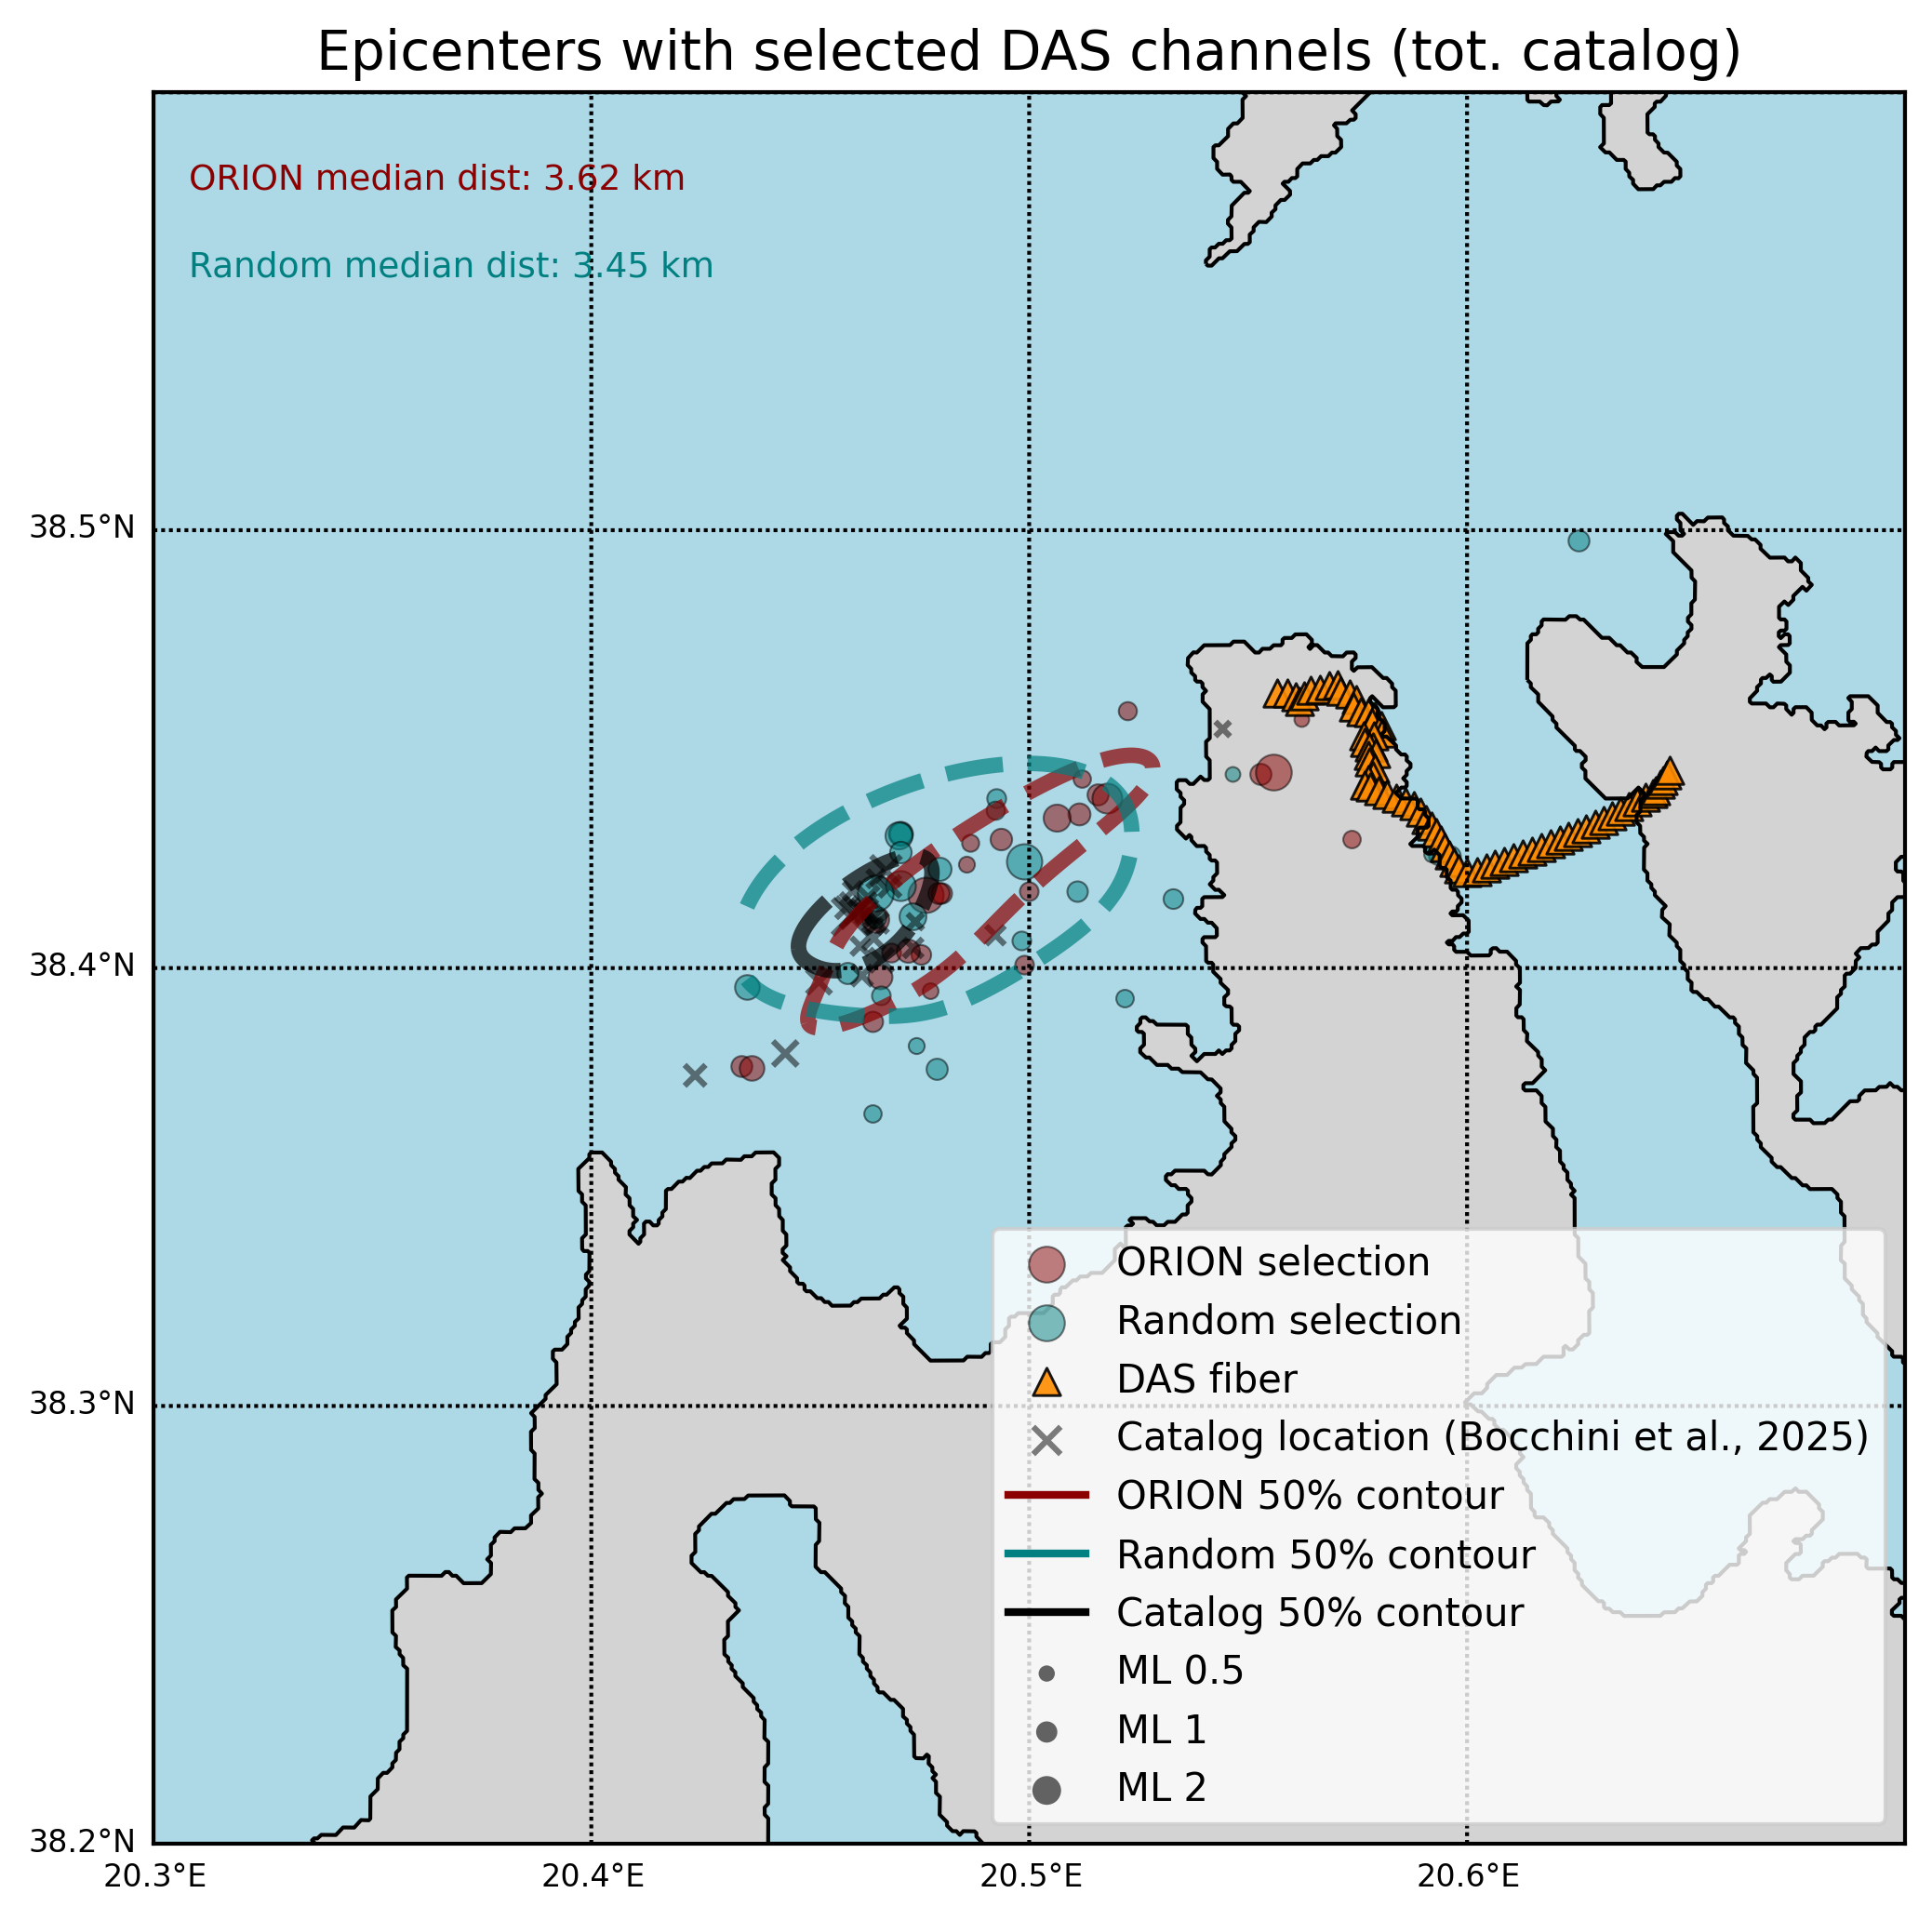

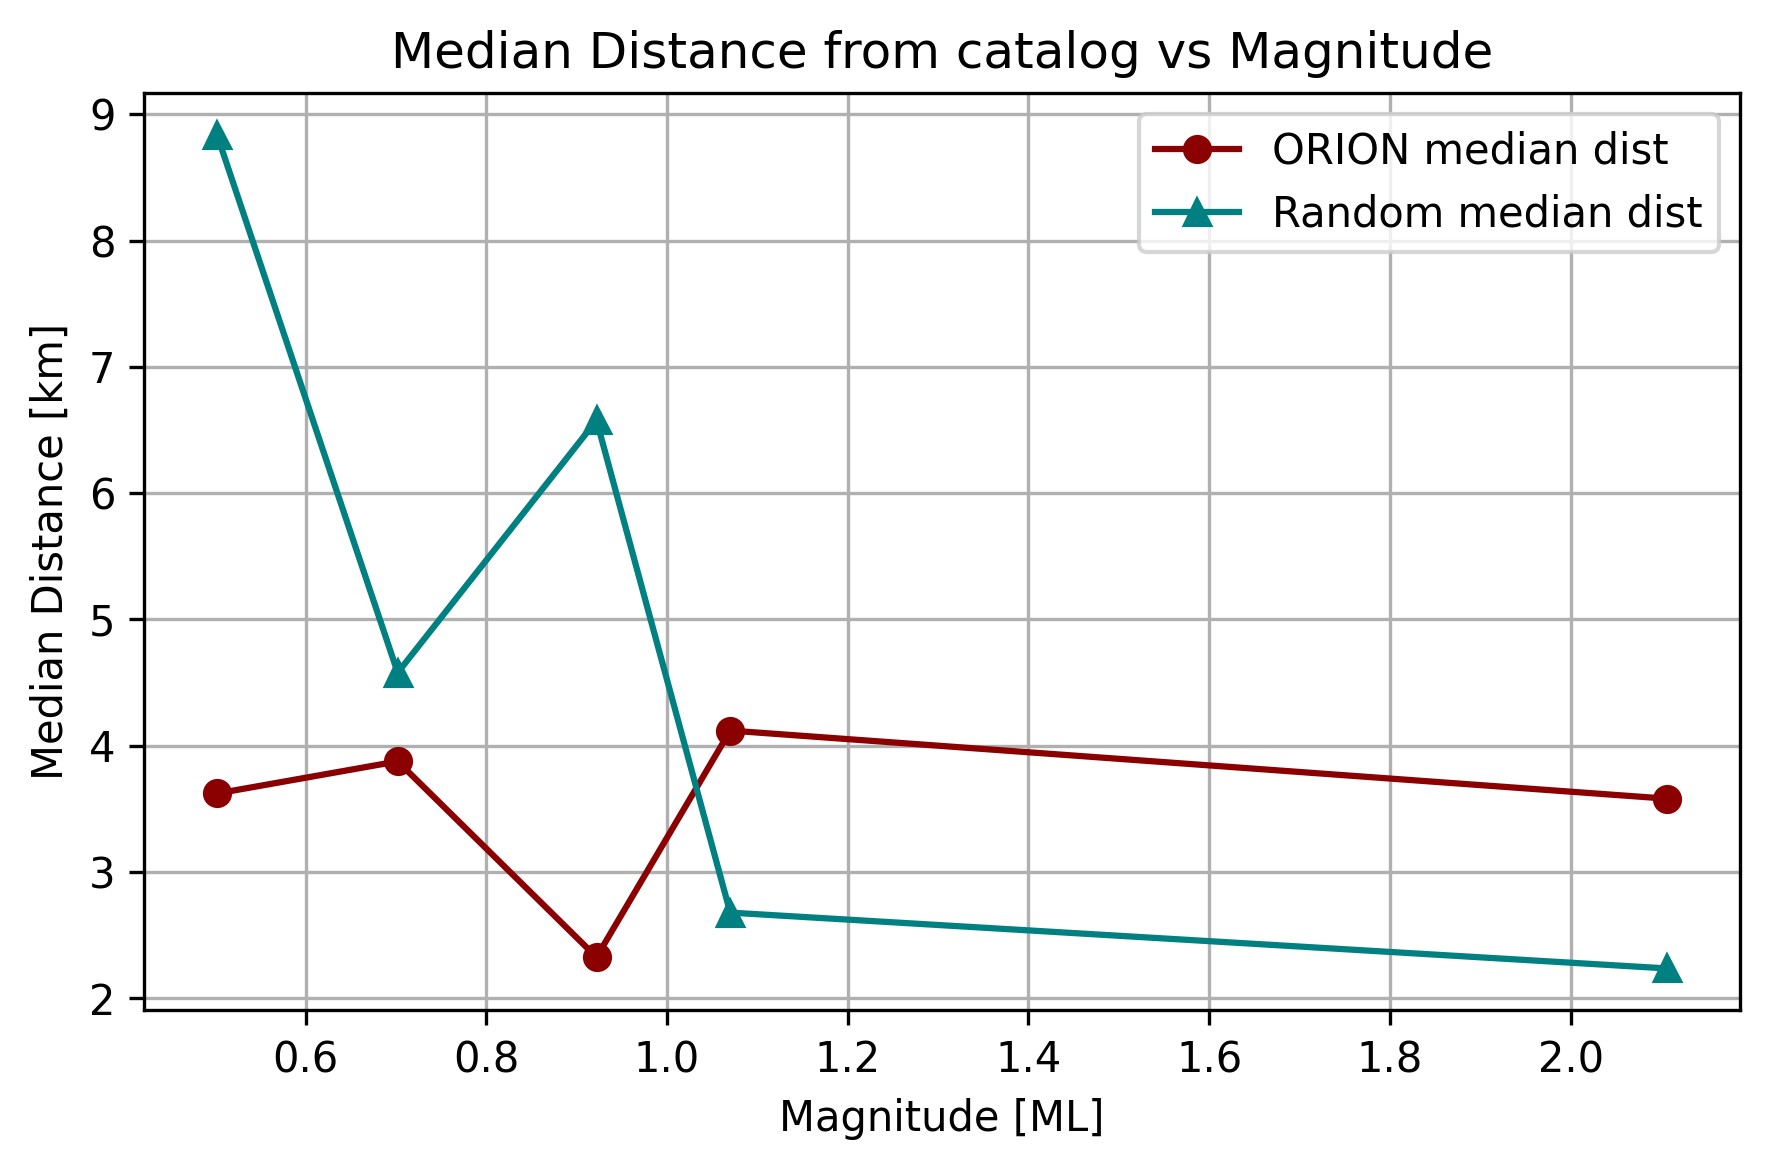

In [ ]:
plot_fiber_only_map_with_maxima_no_cat(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    magnitude_threshold=0,
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected_2/',
    title="Epicenters with selected DAS channels (tot. catalog)"
      # ← Set your desired threshold here
)


In [1]:
def plot_fiber_only_map_with_maxima_no_cat_single_color(ref_lat, ref_lon, das_hyb,
                                                        earthquake_location, cartesian_grid_x,
                                                        cartesian_grid_y, lat_range, lon_range,
                                                        parent_folder,
                                                        title="Fiber Maxima Map"):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from scipy.ndimage import zoom
    import numpy as np
    import os
    import glob
    import pandas as pd
    import re
    from scipy.stats import gaussian_kde
    from matplotlib.patches import Patch
    from matplotlib import rcParams

    # Set matplotlib parameters for a clean, high-quality look (sans-serif font)
    rcParams.update({
        'font.size': 14,
        'axes.labelsize': 15,
        'axes.titlesize': 18,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'legend.fontsize': 13,
        'figure.dpi': 300,
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans'],
        'axes.linewidth': 0.8,
        'lines.linewidth': 1.0,
        'xtick.major.pad': 7,  # Increase distance between ticks and x labels
        'ytick.major.pad': 7,  # Increase distance for y labels (latitude)
    })

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def collect_refined_max_locations_for_variant(parent_folder, event_id, variant_suffix):
        folder_name = f"{event_id}{variant_suffix}"
        event_path = os.path.join(parent_folder, folder_name, 'fiber')
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        npy_files = glob.glob(os.path.join(event_path, "corrmatrix_trial_*_fiber.npy"))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)

                window_size = 10
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 10
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)

                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]

                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)

                max_locations.append((lat_max, lon_max))

            except Exception:
                continue

        return max_locations

    legend_entries = []

    def plot_50_percent_density_region(lons, lats, color, label):
        if len(lons) < 5:
            return
        xy = np.vstack([lons, lats])
        kde = gaussian_kde(xy)

        x_grid, y_grid = np.meshgrid(
            np.linspace(lon_range[0], lon_range[1], 500),
            np.linspace(lat_range[0], lat_range[1], 500)
        )
        grid_coords = np.vstack([x_grid.ravel(), y_grid.ravel()])
        z = kde(grid_coords).reshape(x_grid.shape)

        z_flat = z.ravel()
        z_sorted = np.sort(z_flat)[::-1]
        cumsum = np.cumsum(z_sorted)
        cumsum /= cumsum[-1]

        threshold_idx = np.searchsorted(cumsum, 0.5)
        threshold_value = z_sorted[threshold_idx]

        z_masked = np.ma.masked_less(z, threshold_value)

        ax.contourf(x_grid, y_grid, z_masked, levels=1, colors=[color], alpha=0.2)
        ax.contour(x_grid, y_grid, z, levels=[threshold_value], colors=color, linewidths=1.5, linestyles='solid', alpha=0.85)

        patch = Patch(facecolor=color, edgecolor='k', alpha=0.2, label=label)
        legend_entries.append(patch)

    folder_list = os.listdir(parent_folder)
    pattern = re.compile(r'^(.*)_(orion|random)$')
    event_ids = set()
    for folder in folder_list:
        m = pattern.match(folder)
        if m:
            event_ids.add(m.group(1))
    event_ids = sorted(list(event_ids))

    all_orion_lats, all_orion_lons = [], []
    all_random_lats, all_random_lons = [], []

    fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='f', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')

    parallels = np.arange(lat_range[0], lat_range[1] + 0.01, 0.1)
    meridians = np.arange(lon_range[0], lon_range[1] + 0.01, 0.1)

    # Draw parallels with labels on left only
    m.drawparallels(parallels, labels=[1, 0, 0, 0], fontsize=13, linewidth=0.3, color='gray', dashes=[2, 2])
    # Draw meridians with labels on bottom only
    m.drawmeridians(meridians, labels=[0, 0, 0, 1], fontsize=13, linewidth=0.3, color='gray', dashes=[2, 2])

    # Manually adjust y-axis label padding to avoid overlap with ticks
    ax.yaxis.labelpad = 15
    ax.xaxis.labelpad = 10

    # Fix latitude label overlap by shifting them slightly left
    for txt in ax.get_yticklabels():
        x, y = txt.get_position()
        txt.set_position((x - 0.5, y))  # tweak the shift value if needed


    for event_id in event_ids:
        orion_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_orion')
        for lat, lon in orion_pts:
            ax.scatter(lon, lat, marker='o', color='darkred', edgecolor='k', linewidths=0.5, s=80, alpha=0.7, label='ORION')
            all_orion_lats.append(lat)
            all_orion_lons.append(lon)

        random_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_random')
        for lat, lon in random_pts:
            ax.scatter(lon, lat, marker='o', color='teal', edgecolor='k', linewidths=0.5, s=80, alpha=0.7, label='Random')
            all_random_lats.append(lat)
            all_random_lons.append(lon)

    plot_50_percent_density_region(all_orion_lons, all_orion_lats, color='darkred', label='Orion 50% density region')
    plot_50_percent_density_region(all_random_lons, all_random_lats, color='teal', label='Random 50% density region')

    # --- DAS channels from CSV ---
    das_csv_path = "/home/emanuele/data/emanuele/loki-das/cefalonia/geometry"
    try:
        for file in os.listdir(das_csv_path):
            if file.endswith(".csv"):
                csv_file = os.path.join(das_csv_path, file)
                df_das = pd.read_csv(csv_file)

                if "latitude" in df_das.columns and "longitude" in df_das.columns:
                    sampled_df = df_das.iloc[::100]  # every 100th point
                    ax.scatter(sampled_df["longitude"], sampled_df["latitude"],
                               marker='^', color='darkorange', linewidths=0.7, edgecolor='k', s=50,
                               alpha=0.9, label="DAS fiber")
                break
    except Exception as e:
        print(f"Error loading DAS channel CSV: {e}")

    ax.set_title(title, fontsize=20, weight='normal', pad=15)
    ax.set_xlabel("Longitude", fontsize=16)
    ax.set_ylabel("Latitude", fontsize=16)

    handles, labels = ax.get_legend_handles_labels()
    handles += legend_entries
    labels += [h.get_label() for h in legend_entries]

    # Remove duplicate legend entries while preserving order
    unique = dict()
    for h, l in zip(handles, labels):
        if l not in unique:
            unique[l] = h

    ax.legend(unique.values(), unique.keys(), loc='upper right', fontsize=13,
              frameon=True, shadow=False, fancybox=True)

    plt.tight_layout()
    plt.show()


In [2]:
plot_fiber_only_map_with_maxima_no_cat_single_color(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection/',
    title="LION with auto-selected DAS channels"
)


NameError: name 'cartesian_grid_x' is not defined

In [8]:
def plot_fiber_only_map_with_maxima(ref_lat, ref_lon, das_hyb,
                                    earthquake_location, cartesian_grid_x,
                                    cartesian_grid_y, lat_range, lon_range,
                                    parent_folder,
                                    title="Fiber Maxima Map (with non-selected)"):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from matplotlib.lines import Line2D
    from scipy.ndimage import zoom
    import numpy as np
    import os
    import glob
    import pandas as pd
    import re
    from matplotlib import cm

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        phi1 = np.radians(lat1)
        phi2 = np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)

        a = np.sin(dphi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        return R * c

    def collect_refined_max_locations_for_variant(parent_folder, event_id, variant_suffix):
        folder_name = f"{event_id}{variant_suffix}"
        event_path = os.path.join(parent_folder, folder_name, 'fiber')
        max_locations = []
        nx, ny = cartesian_grid_x.shape

        if not os.path.isdir(event_path):
            return max_locations

        npy_files = glob.glob(os.path.join(event_path, "corrmatrix_trial_*_fiber.npy"))

        for file in npy_files:
            try:
                corrmatrix_das = np.load(file)
                total_size = corrmatrix_das.size
                if total_size % (nx * ny) != 0:
                    continue

                nz = total_size // (nx * ny)
                corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                CXY = np.max(corrmatrix, axis=2).T

                coarse_max_idx = np.unravel_index(np.nanargmax(CXY), CXY.shape)

                window_size = 10
                i_min = max(coarse_max_idx[0] - window_size, 0)
                i_max = min(coarse_max_idx[0] + window_size + 1, CXY.shape[0])
                j_min = max(coarse_max_idx[1] - window_size, 0)
                j_max = min(coarse_max_idx[1] + window_size + 1, CXY.shape[1])

                CXY_local = CXY[i_min:i_max, j_min:j_max]
                x_local = cartesian_grid_x[i_min:i_max, j_min:j_max]
                y_local = cartesian_grid_y[i_min:i_max, j_min:j_max]

                zoom_factor = 10
                CXY_fine = zoom(CXY_local, zoom_factor, order=3)
                x_fine = zoom(x_local, zoom_factor, order=1)
                y_fine = zoom(y_local, zoom_factor, order=1)

                fine_max_idx = np.unravel_index(np.nanargmax(CXY_fine), CXY_fine.shape)

                x_max = x_fine[fine_max_idx]
                y_max = y_fine[fine_max_idx]

                lat_max, lon_max = cartesian_to_geographic(x_max, y_max, ref_lat, ref_lon)
                max_locations.append((lat_max, lon_max))
            except Exception:
                continue

        return max_locations

    # Load catalog
    catalog_path = os.path.join(parent_folder, 'catalog_17072025.csv')
    catalog_df = pd.read_csv(catalog_path)
    valid_evids = set(catalog_df['evid'].astype(str))
    evid_to_coords = {str(row['evid']): (row['latitude'], row['longitude']) for _, row in catalog_df.iterrows()}

    # Detect event IDs from folder names with _variant suffix
    folder_list = os.listdir(parent_folder)
    pattern = re.compile(r'^(.*)_(orion|random|non_selected)$')
    event_ids = set()
    for folder in folder_list:
        m = pattern.match(folder)
        if m:
            event_ids.add(m.group(1))

    event_ids = sorted(list(event_ids))
# Filter to IDs <= '0844' (preserving leading zeros)
# Filter event IDs from '0021' to '0844' inclusive
    #event_ids = sorted([
    #    eid for eid in event_ids
    #    if re.search(r'\d+', eid) and int(re.search(r'\d+', eid).group()) <= 845
    #])

    total_events = len(event_ids)

    # Assign colors
    tab20c_colors = cm.get_cmap('tab20').colors
    event_color_map = {}
    for i, eid in enumerate(event_ids):
        color = tab20c_colors[i % len(tab20c_colors)] if i < len(tab20c_colors) else (0.5, 0.5, 0.5)
        event_color_map[eid] = color

    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.2), labels=[1, 0, 0, 0], fontsize=8)
    m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.2), labels=[0, 0, 0, 1], fontsize=8)

    # Global distance lists
    all_dists_orion = []
    all_dists_random = []
    all_dists_non_selected = []

    for event_id in event_ids:
        color = event_color_map[event_id]
        has_catalog = event_id in evid_to_coords

        if has_catalog:
            lat_cat, lon_cat = evid_to_coords[event_id]
            ax.scatter(lon_cat, lat_cat, marker='*', color=color, edgecolor='k', linewidths=1, s=40, alpha=0.7, label=f"{event_id} Catalog")
        else:
            print(f"[info] No catalog location for event {event_id}")
            lat_cat, lon_cat = None, None

        # Orion
        orion_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_orion')
        for lat, lon in orion_pts:
            ax.scatter(lon, lat, marker='o', color=color, edgecolor='k', linewidths=0.5, s=20, alpha=0.7, label=f"{event_id} Orion")
            if lat_cat is not None:
                all_dists_orion.append(haversine(lat_cat, lon_cat, lat, lon))

        # Random
        random_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_random')
        for lat, lon in random_pts:
            ax.scatter(lon, lat, marker='s', color=color, edgecolor='k', linewidths=0.5, s=20, alpha=0.7, label=f"{event_id} Random")
            if lat_cat is not None:
                all_dists_random.append(haversine(lat_cat, lon_cat, lat, lon))

        # Non-selected
        non_selected_pts = collect_refined_max_locations_for_variant(parent_folder, event_id, '_non_selected')
        for lat, lon in non_selected_pts:
            ax.scatter(lon, lat, marker='x', color=color, edgecolor='k', linewidths=0.5, s=20, alpha=0.7, label=f"{event_id} Non-selected")
            if lat_cat is not None:
                all_dists_non_selected.append(haversine(lat_cat, lon_cat, lat, lon))

    # Distance stats
    if all_dists_orion:
        print(f"[GLOBAL] Mean Orion distance: {np.mean(all_dists_orion):.2f} km")
    if all_dists_random:
        print(f"[GLOBAL] Mean Random distance: {np.mean(all_dists_random):.2f} km")
    if all_dists_non_selected:
        print(f"[GLOBAL] Mean Non-selected distance: {np.mean(all_dists_non_selected):.2f} km")

    # DAS station locations
    for name, (lat, lon) in das_hyb.items():
        ax.scatter(lon, lat, marker='^', color='black', edgecolor='k', s=25, label='DAS fiber')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    #ax.legend(unique.values(), unique.keys(), loc='upper right', fontsize='x-small', frameon=True)

    # Orion histogram
    if all_dists_orion:
        fig_orion, ax_orion = plt.subplots(figsize=(6, 4), dpi=150)
        ax_orion.hist(all_dists_orion, bins=20, color='blue', edgecolor='black', alpha=0.7)
        ax_orion.axvline(np.median(all_dists_orion), color='red', linestyle='--', label=f"Median = {np.median(all_dists_orion):.2f} km")
        ax_orion.set_title("Histogram of Orion Maxima Distances")
        ax_orion.set_xlabel("Distance from Catalog Location (km)")
        ax_orion.set_ylabel("Number of Maxima")
        ax_orion.set_ylim([0, 100])
        ax_orion.legend()
        ax_orion.grid(True)

    # Random histogram
    if all_dists_random:
        fig_random, ax_random = plt.subplots(figsize=(6, 4), dpi=150)
        ax_random.hist(all_dists_random, bins=20, color='green', edgecolor='black', alpha=0.7)
        ax_random.axvline(np.median(all_dists_random), color='red', linestyle='--', label=f"Median = {np.median(all_dists_random):.2f} km")
        ax_random.set_title("Histogram of Random Maxima Distances")
        ax_random.set_xlabel("Distance from Catalog Location (km)")
        ax_random.set_ylabel("Number of Maxima")
        ax_random.set_ylim([0, 100])
        ax_random.legend()
        ax_random.grid(True)

    # Non-selected histogram
    if all_dists_non_selected:
        fig_non, ax_non = plt.subplots(figsize=(6, 4), dpi=150)
        ax_non.hist(all_dists_non_selected, bins=20, color='orange', edgecolor='black', alpha=0.7)
        ax_non.axvline(np.median(all_dists_non_selected), color='red', linestyle='--', label=f"Median = {np.median(all_dists_non_selected):.2f} km")
        ax_non.set_title("Histogram of Non-selected Maxima Distances")
        ax_non.set_xlabel("Distance from Catalog Location (km)")
        ax_non.set_ylabel("Number of Maxima")
        ax_non.set_ylim([0, 100])
        ax_non.legend()
        ax_non.grid(True)

    plt.show()


[info] No catalog location for event kef0021


/home/emanuele/miniconda3/envs/loki-DAS-ema/lib/python3.7/site-packages/ipykernel_launcher.py:162: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.


[info] No catalog location for event kef0191
[info] No catalog location for event kef0200
[info] No catalog location for event kef0225
[info] No catalog location for event kef0273
[info] No catalog location for event kef0279
[info] No catalog location for event kef0413
[info] No catalog location for event kef0584
[info] No catalog location for event kef0752
[info] No catalog location for event kef1379
[info] No catalog location for event kef1401
[info] No catalog location for event kef1449
[info] No catalog location for event kef1677
[GLOBAL] Mean Orion distance: 4.60 km
[GLOBAL] Mean Random distance: 5.86 km
[GLOBAL] Mean Non-selected distance: 4.22 km


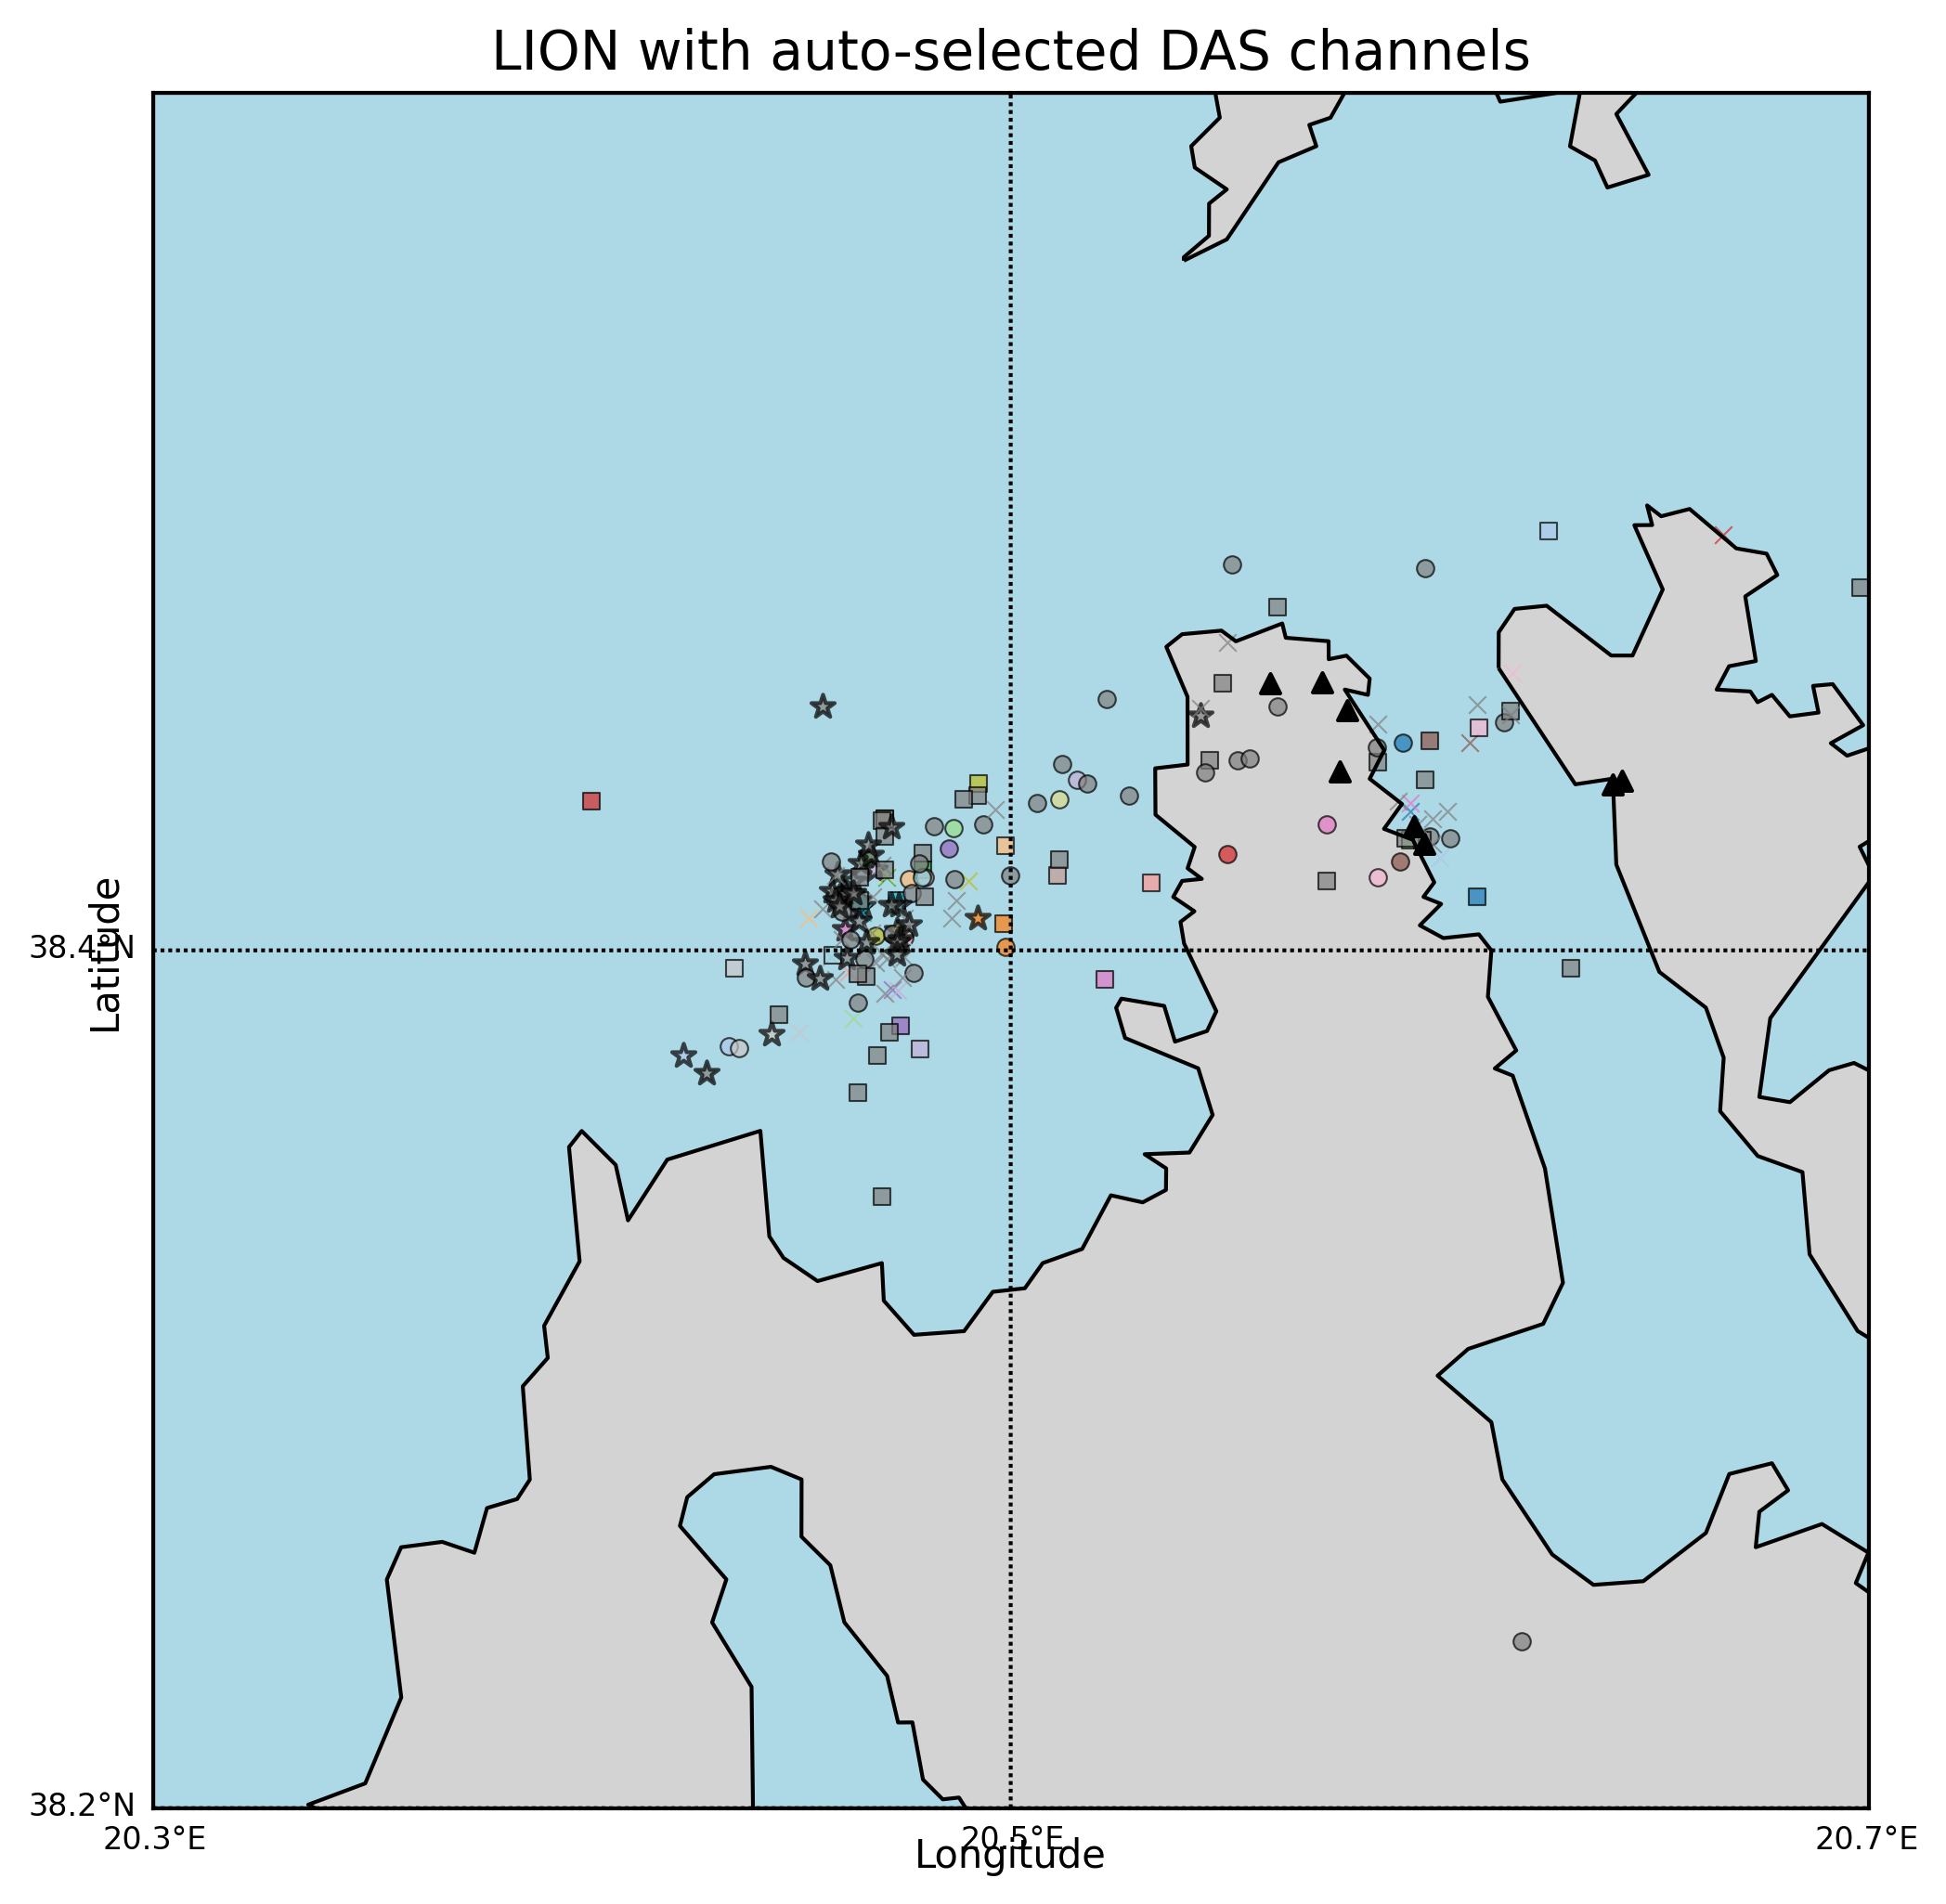

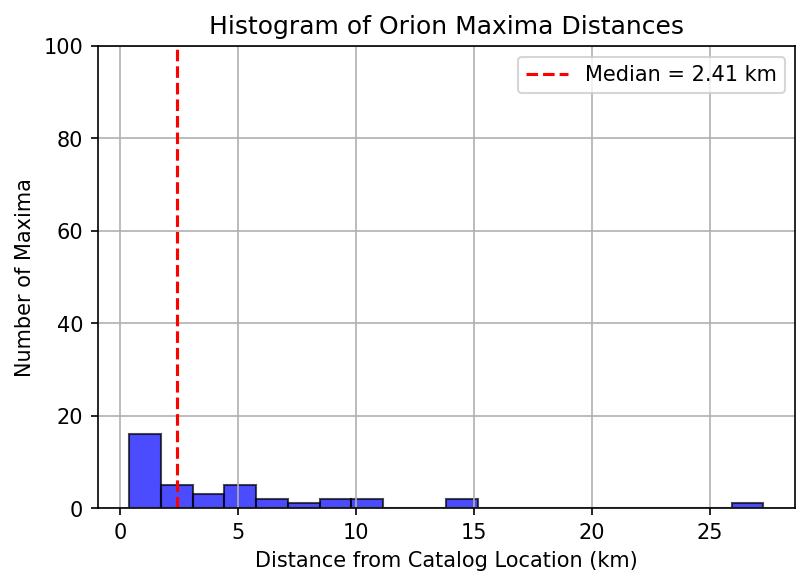

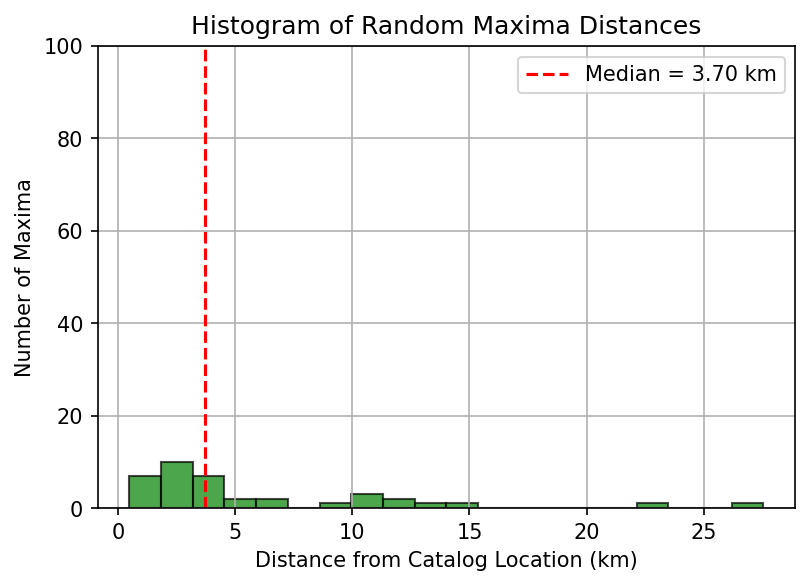

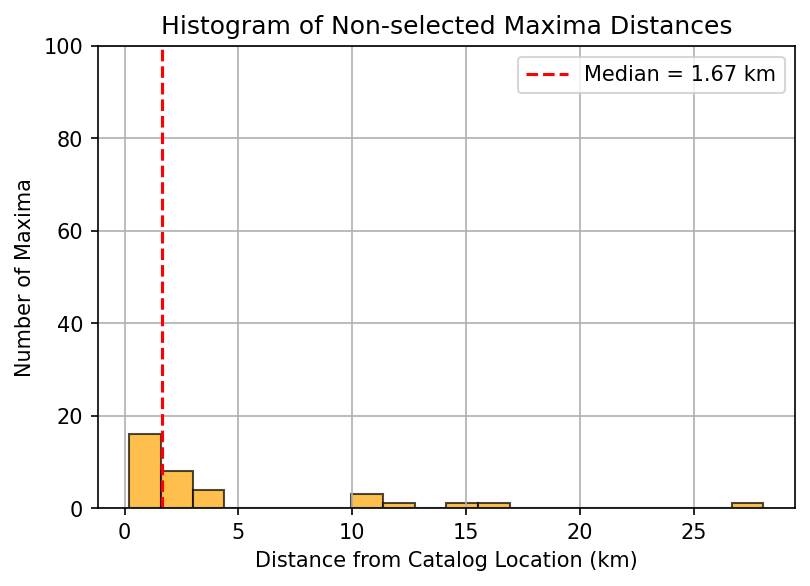

In [9]:
plot_fiber_only_map_with_maxima(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.2, 38.6),
    lon_range=(20.3, 20.7),
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_das_high_freq_complete_weak_subsection_also_non_selected/',
    title="LION with auto-selected DAS channels"
)


In [37]:
def plot_fiber_only_map_with_percentile_sum(ref_lat, ref_lon, das_hyb,
                                            earthquake_location, cartesian_grid_x,
                                            cartesian_grid_y, lat_range, lon_range,
                                            parent_folder, title="Fiber 99th Percentile Sum Map"):
    import matplotlib.pyplot as plt
    from mpl_toolkits.basemap import Basemap
    from matplotlib.colors import Normalize
    from matplotlib import cm
    from scipy.interpolate import griddata
    import numpy as np
    import os
    import glob

    def cartesian_to_geographic(x, y, origin_lat, origin_lon):
        earth_radius = 6371  # km
        lat = origin_lat + (y / earth_radius) * (180 / np.pi)
        lon = origin_lon + (x / (earth_radius * np.cos(np.radians(origin_lat)))) * (180 / np.pi)
        return lat, lon

    def collect_percentile_sum(folder_path):
        nx, ny = cartesian_grid_x.shape
        percentile_sum = np.zeros((ny, nx))  # Shape: (lat, lon)

        for event_folder in os.listdir(folder_path):
            event_path = os.path.join(folder_path, event_folder, 'fiber')
            if not os.path.isdir(event_path):
                continue

            npy_files = glob.glob(os.path.join(event_path, "corrmatrix_trial_*_fiber.npy"))
            for file in npy_files:
                try:
                    corrmatrix_das = np.load(file)
                    total_size = corrmatrix_das.size
                    if total_size % (nx * ny) != 0:
                        raise ValueError(f"File {file} shape is incompatible with grid size.")

                    nz = total_size // (nx * ny)
                    corrmatrix = corrmatrix_das.reshape((nx, ny, nz))
                    corrmatrix = corrmatrix / np.nanmax(corrmatrix)
                    CXY = np.nanpercentile(corrmatrix, 99, axis=2).T  # Shape: (ny, nx)
                    percentile_sum += np.nan_to_num(CXY)
                except Exception as e:
                    print(f"Failed to process {file}: {e}")
        return percentile_sum

    percentile_sum = collect_percentile_sum(parent_folder)

    fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
    m = Basemap(projection='cyl', llcrnrlat=lat_range[0], urcrnrlat=lat_range[1],
                llcrnrlon=lon_range[0], urcrnrlon=lon_range[1], resolution='h', ax=ax)

    m.drawcoastlines()
    m.drawcountries()
    m.fillcontinents(color='lightgray', lake_color='lightblue')
    m.drawmapboundary(fill_color='lightblue')
    m.drawparallels(np.arange(lat_range[0], lat_range[1] + 0.01, 0.2), labels=[1,0,0,0], fontsize=8)
    m.drawmeridians(np.arange(lon_range[0], lon_range[1] + 0.01, 0.2), labels=[0,0,0,1], fontsize=8)

    # Convert grid to lat/lon
    lat_grid, lon_grid = cartesian_to_geographic(cartesian_grid_x, cartesian_grid_y, ref_lat, ref_lon)

    # Plot 99th percentile summed heatmap
    norm = Normalize(vmin=np.min(percentile_sum), vmax=np.max(percentile_sum))
    sc = ax.pcolormesh(lon_grid, lat_grid, percentile_sum, cmap=cm.inferno, shading='auto', norm=norm)

    # Plot earthquake catalog location
    ax.scatter(earthquake_location[1], earthquake_location[0], marker='*', color='red', edgecolors='black', s=130, label='Cluster Location')

    # Plot DAS HYB stations
    for name, (lat, lon) in das_hyb.items():
        ax.scatter(lon, lat, marker='o', color='crimson', s=14)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
    cbar.set_label("Summed 99th Percentile Coherence")

    ax.legend(loc='lower right', fontsize='small', frameon=True)
    plt.savefig("fiber_99th_percentile_sum_map.pdf", bbox_inches='tight')
    plt.show()


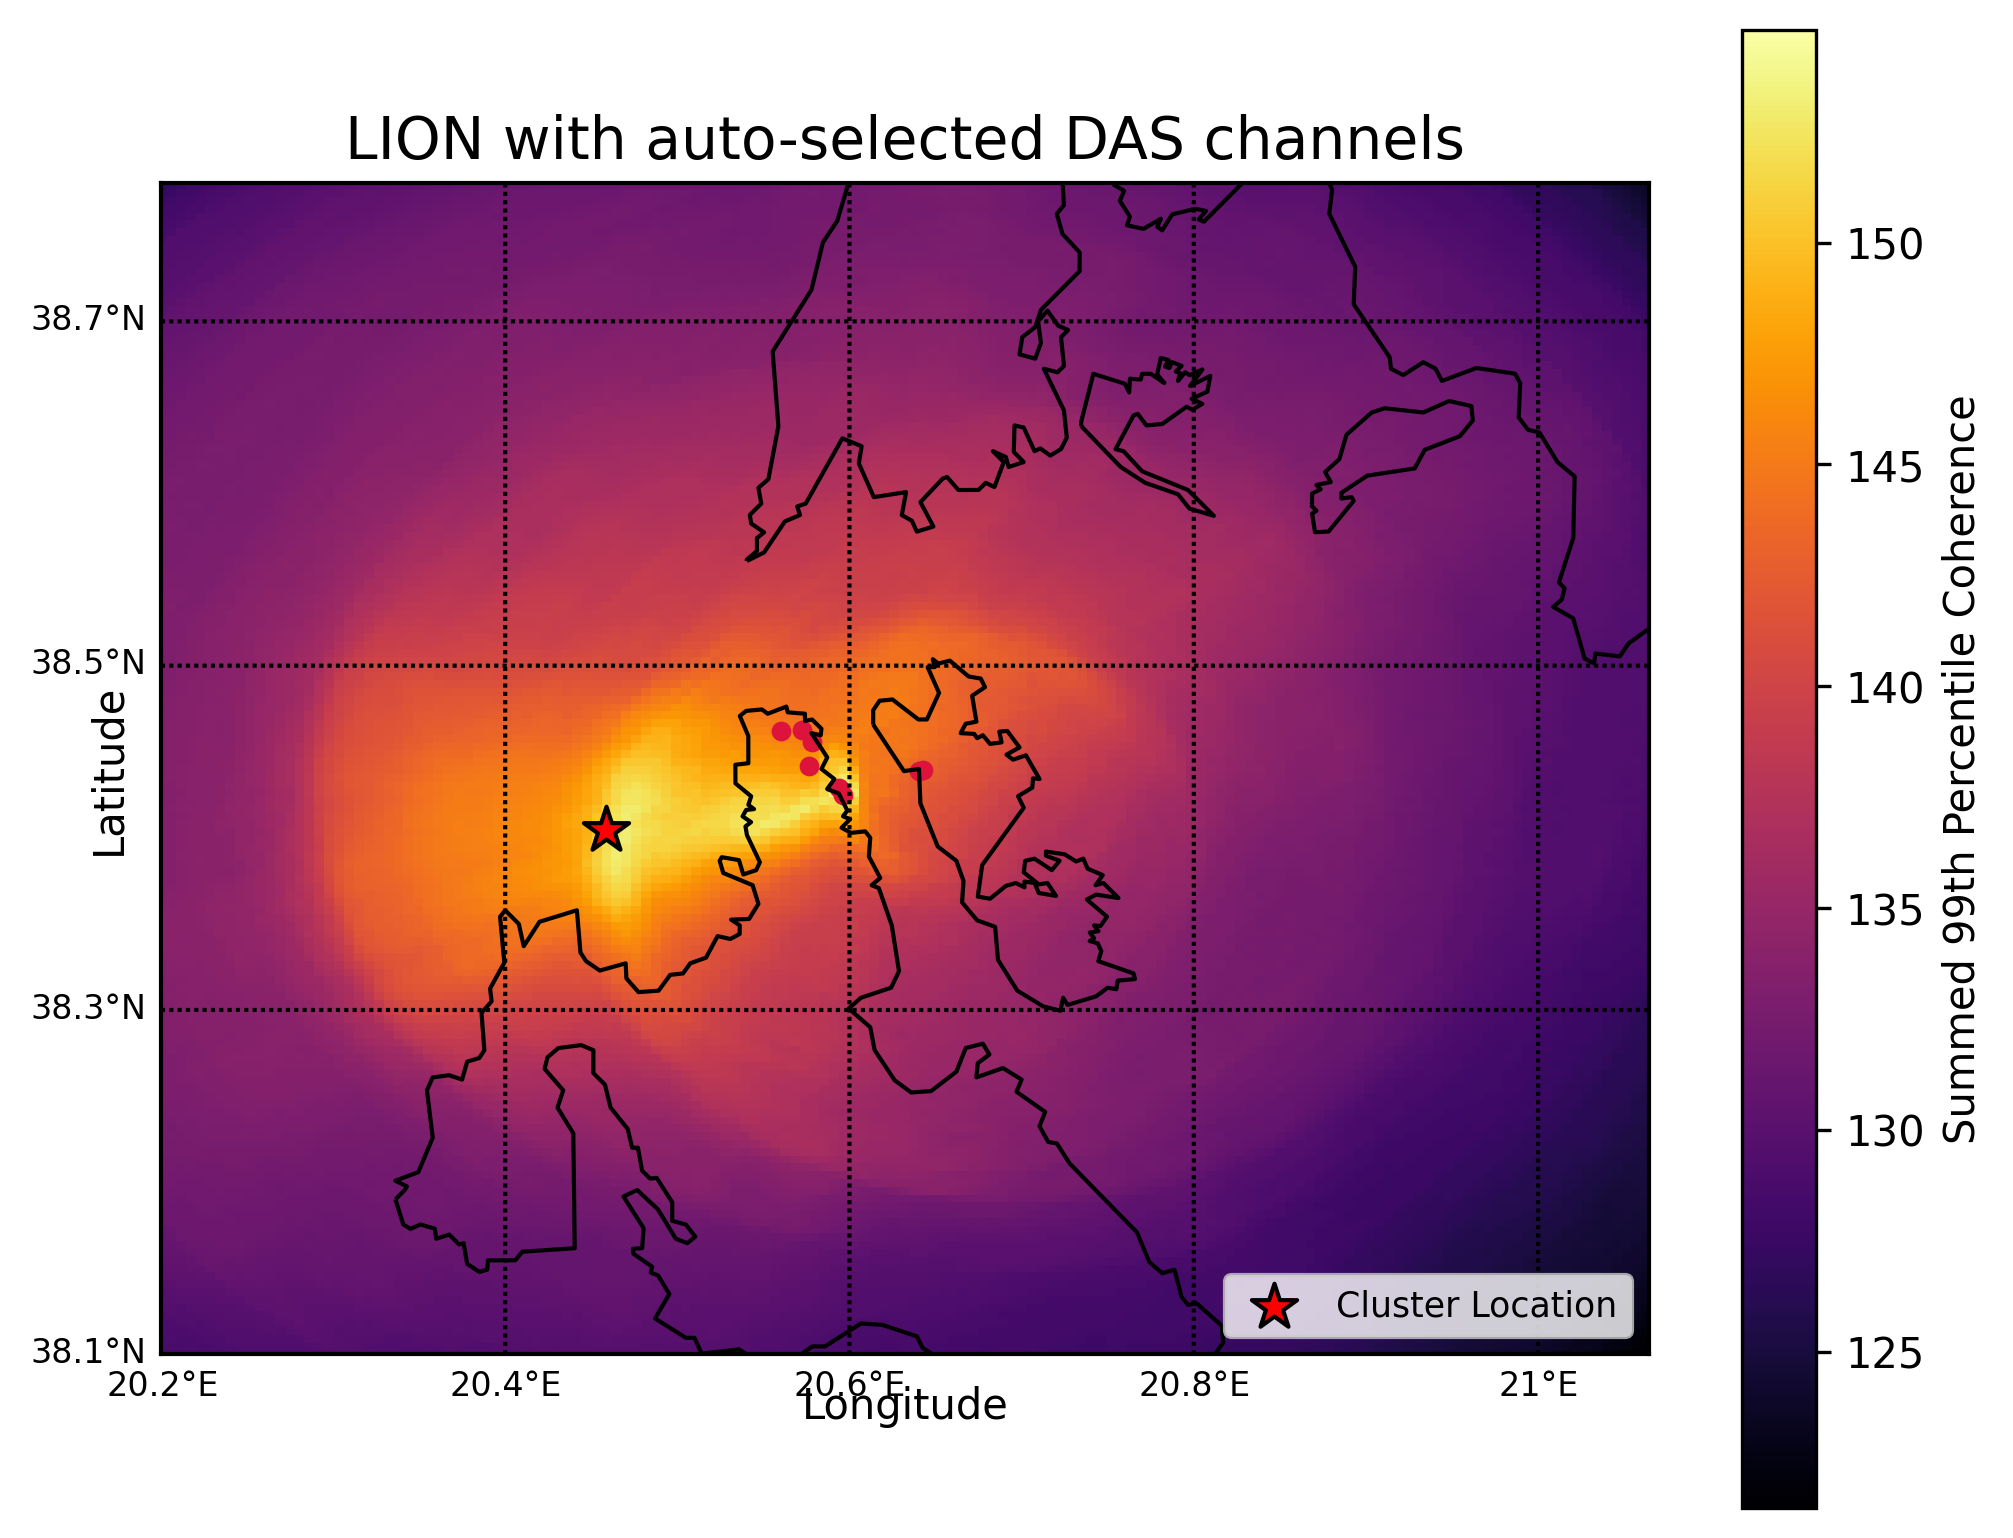

In [6]:
plot_fiber_only_map_with_percentile_sum(
    ref_lat=38.10,
    ref_lon=20.20,
    das_hyb={
        "FIB-0262 (SEL HYB)": (38.4622, 20.5605),
        "FIB-1092 (SEL HYB)": (38.4626, 20.5725),
        "FIB-1738 (SEL HYB)": (38.4559, 20.5785),
        "FIB-3248 (SEL HYB)": (38.4418, 20.5767),
        "FIB-4512 (SEL HYB)": (38.4289, 20.5941),
        "FIB-4755 (SEL HYB)": (38.4249, 20.5965),
        "FIB-6970 (SEL HYB)": (38.4387, 20.6403),
        "FIB-7197 (SEL HYB)": (38.4395, 20.6426),
    },
    earthquake_location=(38.40435, 20.45875),
    cartesian_grid_x=cartesian_grid_x,
    cartesian_grid_y=cartesian_grid_y,
    lat_range=(38.1, 38.78018018018018),
    lon_range=(20.2, 21.064340969963332),
    parent_folder='/home/emanuele/data/emanuele/loki-das/cefalonia/output_orion_complete',
    title="LION with auto-selected DAS channels"
)
